## Data loading

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import pickle

In [2]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [3]:
def read_text(path):
    # CHANGED (only so it runs on a Mac): try UTF-8 first, then Latin-1 for accented names
    for enc in ("utf-8", "latin-1"):
        try:
            with open(path, "r", encoding=enc) as f:
                return f.read().strip()
        except UnicodeDecodeError:
            continue


def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    # CHANGED: sorted() so the row order is the same on every computer
    # (the ground truth refers to the images by position)
    for file in sorted(os.listdir(dataset_dir)):

        # CHANGED: skip hidden macOS files (.DS_Store, ._bbdd_00001.txt ...)
        if file.startswith("."):
            continue

        # Get filename without extension
        filename = os.path.splitext(file)[0]

        # Create entry if it doesn't already exist
        if filename not in data:
            data[filename] = {
                "image_path": None,
                "image": None,
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            data[filename]["image"] = cv2.imread(image_path)

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            content = read_text(txt_path)

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = lines[0]
                    data[filename]["artwork_name"] = lines[1]

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [4]:
dataset = build_dataset(TRAIN_DIR)

In [5]:
dataset.head()

,image_path,image,artist,artwork_name
0,data/BBDD/bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes
1,data/BBDD/bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room
2,data/BBDD/bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",None,None
3,data/BBDD/bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth
4,data/BBDD/bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV


## TASK 1. DESCRIPTOR --> Basic histogram construction and plotting

In [6]:
BINS = 128

In [7]:
valid_images = dataset["image"].apply(
    lambda img: isinstance(img, np.ndarray)
    and img.ndim == 3
    and img.shape[2] == 3
)

dataset = dataset.loc[valid_images].reset_index(drop=True)

# Gray-level (intensity) histogram: convert to gray and count the pixels in each bin
dataset["histogram"] = dataset["image"].apply(
    lambda img: np.histogram(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), bins=BINS, range=(0, 256))[0]
)

In [8]:
dataset.head()

,image_path,image,artist,artwork_name,histogram
0,data/BBDD/bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes,"[3387, 10755, 13620, 14877, 15286, 14931, 1346..."
1,data/BBDD/bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,data/BBDD/bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",None,None,"[942, 4875, 5459, 5360, 5861, 4602, 1891, 723,..."
3,data/BBDD/bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth,"[437, 958, 1613, 2402, 3253, 4058, 5648, 7218,..."
4,data/BBDD/bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV,"[3, 1, 13, 21, 19, 35, 81, 348, 2015, 5098, 57..."


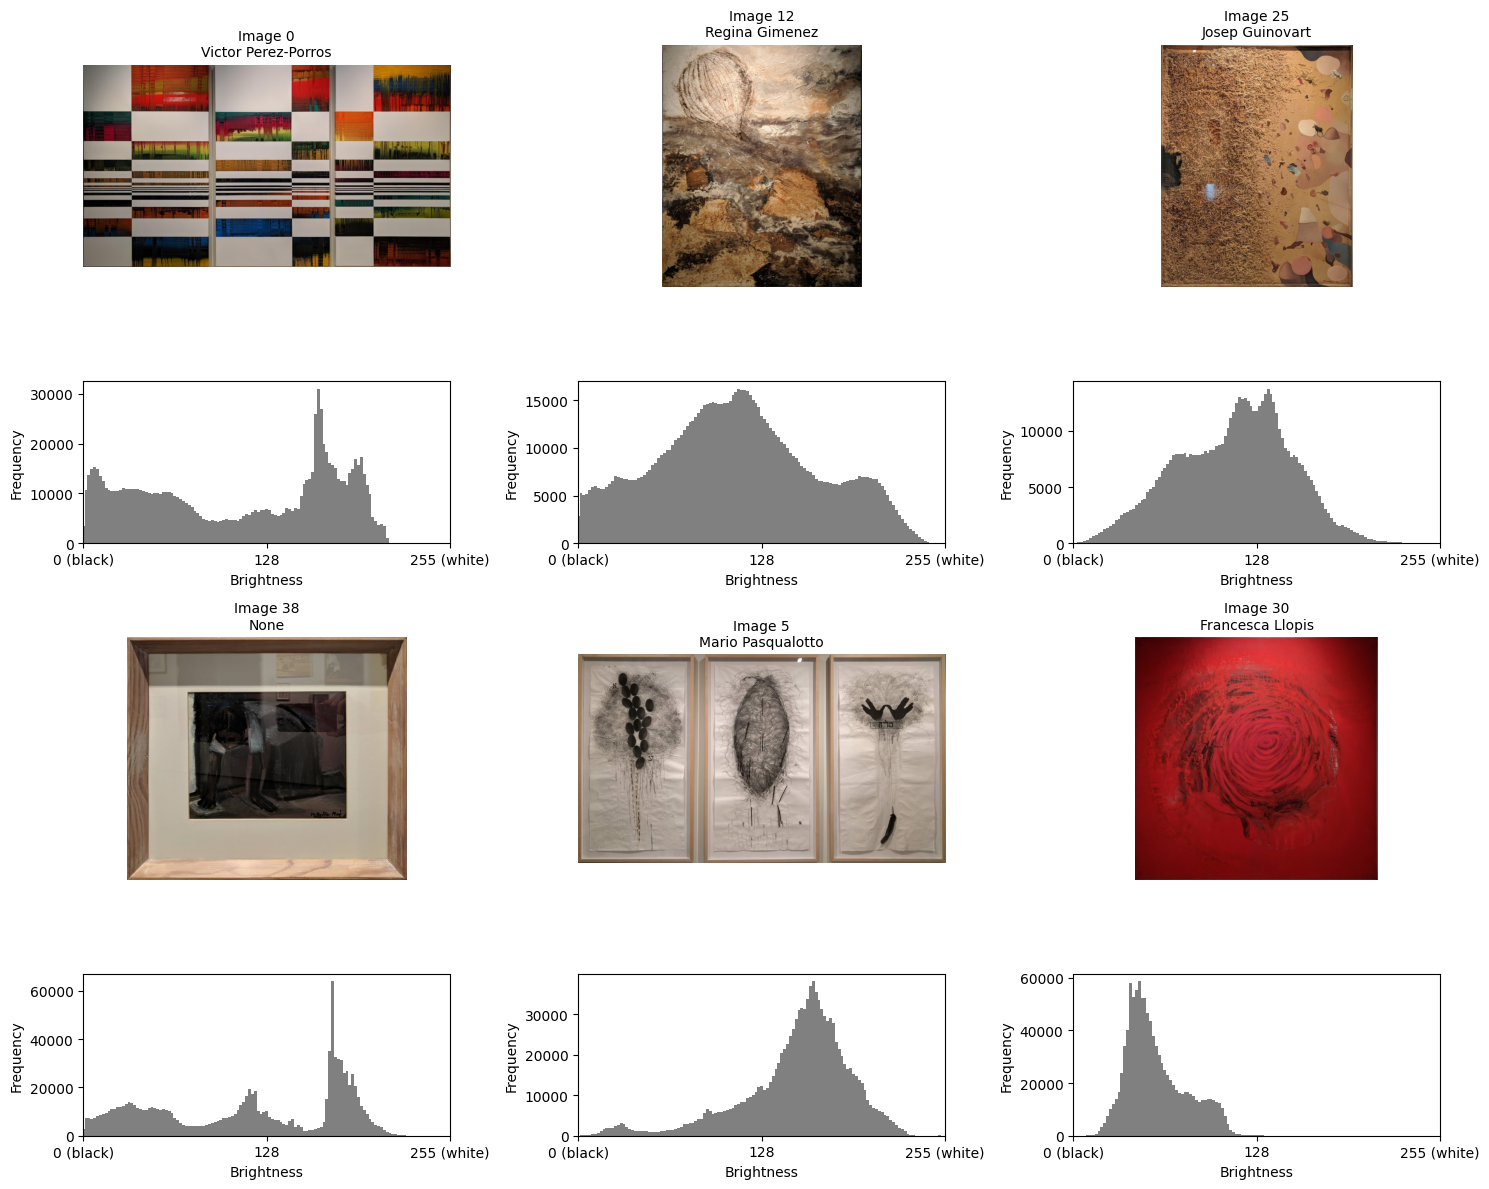

In [ ]:
# Plots of paintings 
indices = [0, 12, 25, 38, 5, 30]    # museum paintings
n_cols = 3                           # paintings per row

n_rows = int(np.ceil(len(indices) / n_cols))
fig, axes = plt.subplots(
    2 * n_rows, n_cols,
    figsize=(5 * n_cols, 6 * n_rows),
    gridspec_kw={"height_ratios": [3, 2] * n_rows},
    squeeze=False,
)

for k, i in enumerate(indices):
    r, c = divmod(k, n_cols)
    ax_img, ax_hist = axes[2 * r, c], axes[2 * r + 1, c]

    # image
    ax_img.imshow(cv2.cvtColor(dataset["image"].iloc[i], cv2.COLOR_BGR2RGB))
    ax_img.set_title(f"Image {i}\n{dataset['artist'].iloc[i]}", fontsize=10)
    ax_img.axis("off")

    # gray histogram (raw pixel counts)
    hist = np.asarray(dataset["histogram"].iloc[i])
    ax_hist.bar(np.arange(len(hist)), hist, color="gray", width=1.0)
    ax_hist.set_xlim(0, len(hist))
    ax_hist.set_xticks([0, len(hist) / 2, len(hist)])
    ax_hist.set_xticklabels(["0 (black)", "128", "255 (white)"])
    ax_hist.set_xlabel("Brightness")
    ax_hist.set_ylabel("Frequency")

# hide the empty slots if the number of paintings does not fill the last row
for k in range(len(indices), n_rows * n_cols):
    r, c = divmod(k, n_cols)
    axes[2 * r, c].axis("off")
    axes[2 * r + 1, c].axis("off")

plt.tight_layout()
plt.show()

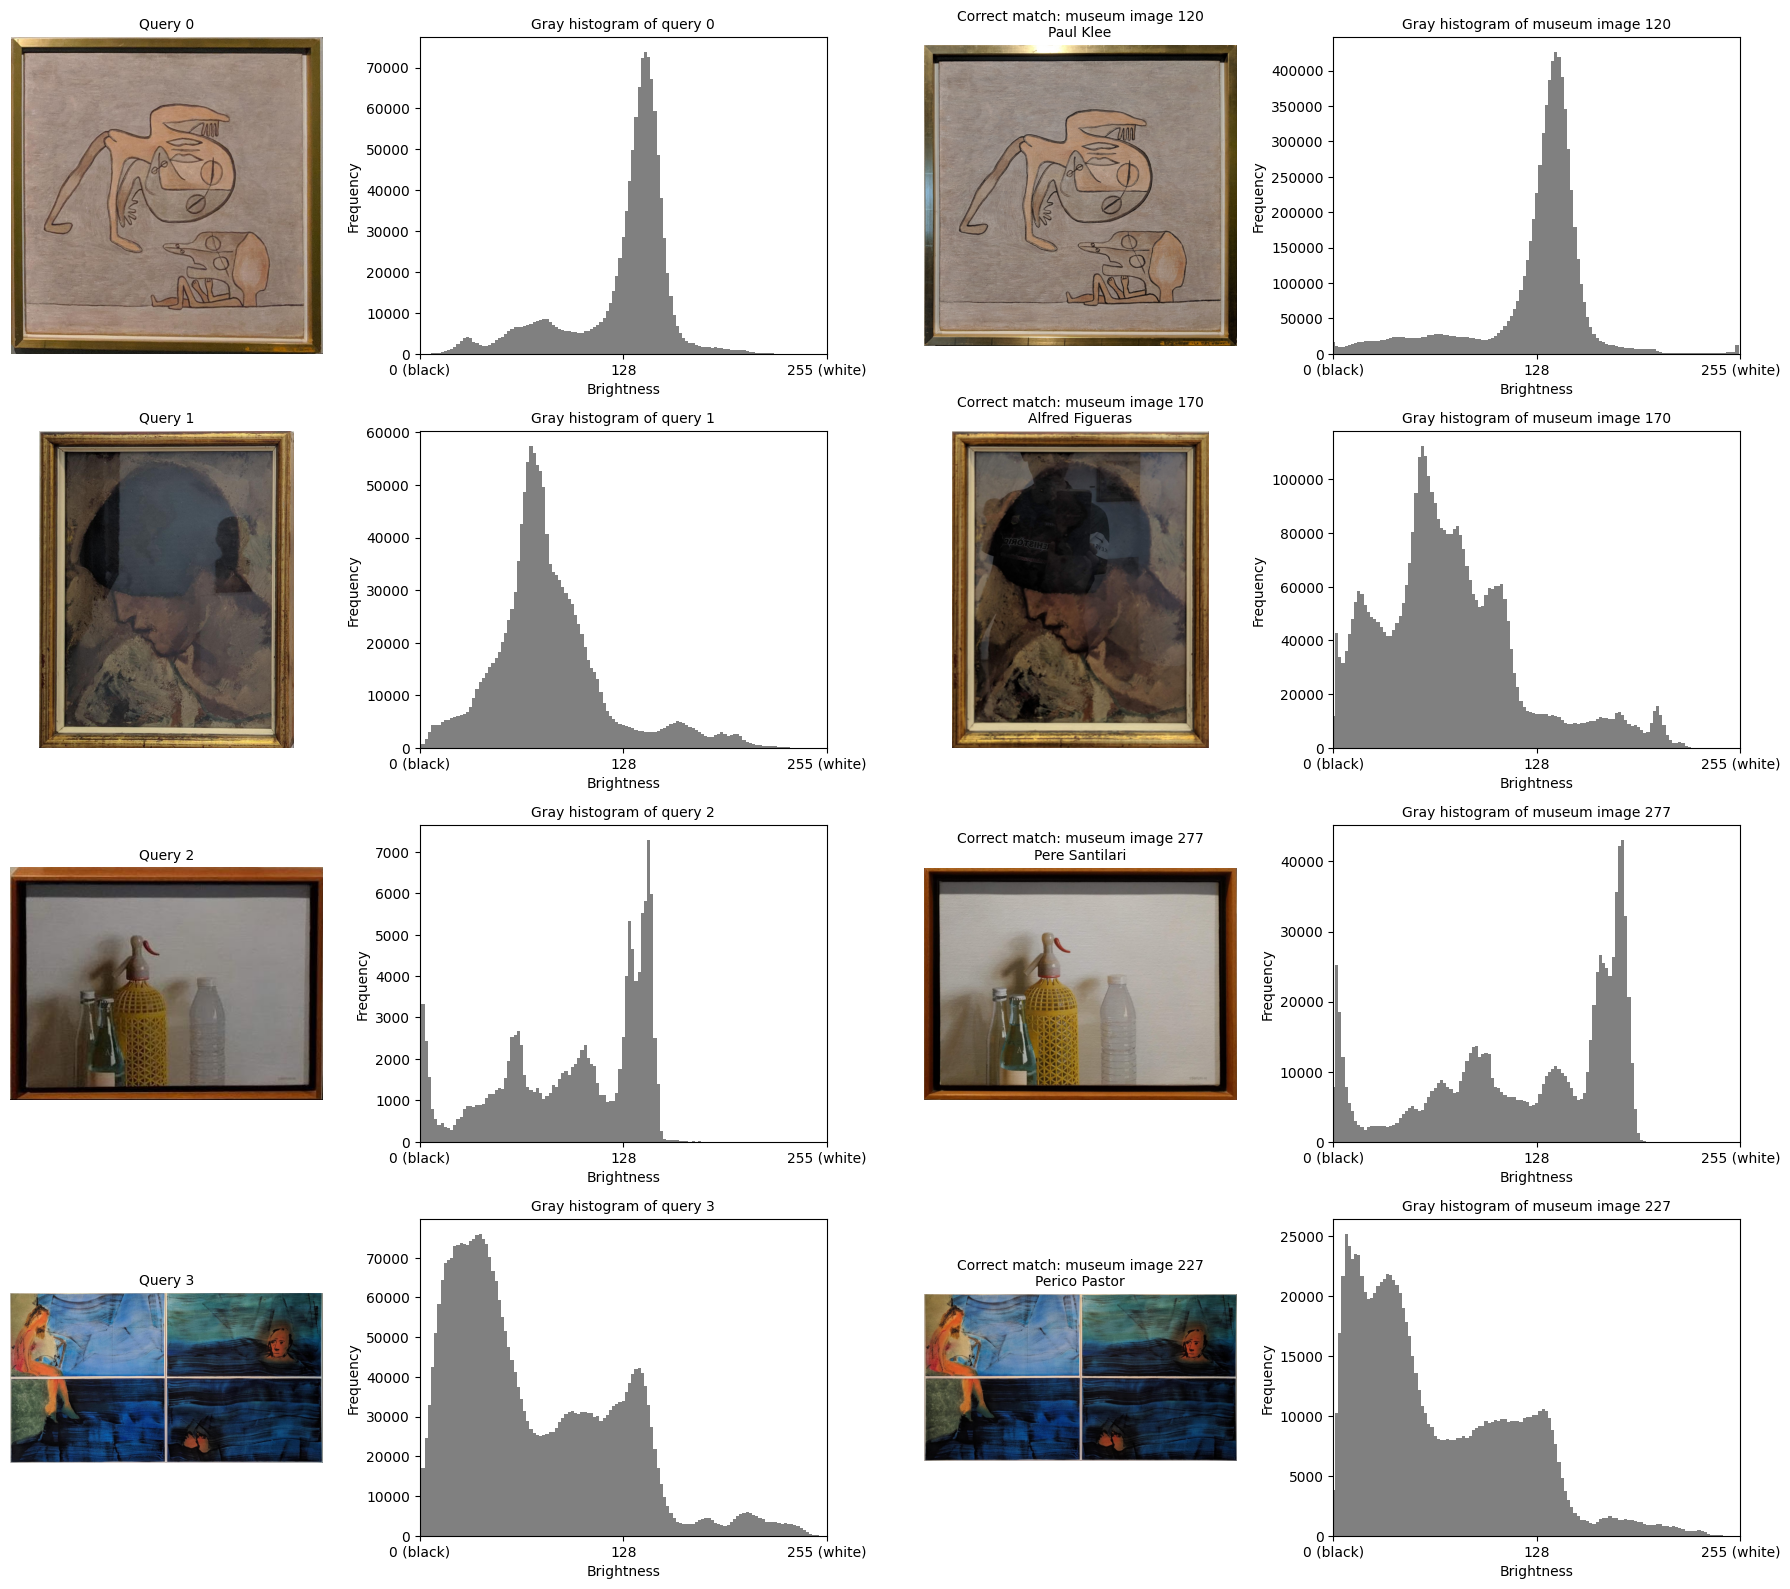

In [ ]:
# Query vs its correct museum painting: image and gray histogram of each, one query per row
query_indices = [0, 1, 2, 3]     # queries


def gray_hist(img):
    return np.histogram(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), bins=BINS, range=(0, 256))[0]


def draw_hist(ax, hist, title):
    ax.bar(np.arange(len(hist)), hist, color="gray", width=1.0)
    ax.set_xlim(0, len(hist))
    ax.set_xticks([0, len(hist) / 2, len(hist)])
    ax.set_xticklabels(["0 (black)", "128", "255 (white)"])
    ax.set_xlabel("Brightness")
    ax.set_ylabel("Frequency")
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(
    len(query_indices), 4,
    figsize=(18, 4 * len(query_indices)),
    gridspec_kw={"width_ratios": [1, 1.3, 1, 1.3]},
    squeeze=False,
)

for row, q in enumerate(query_indices):
    j = int(correspondence_table.iloc[q]["train_index"])    # position of the correct painting in the museum
    query_img = test_rows["image"].iloc[q]
    match_img = train_rows["image"].iloc[j]
    ax_query, ax_query_hist, ax_match, ax_match_hist = axes[row]

    # query: picture and histogram
    ax_query.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
    ax_query.set_title(f"Query {q}", fontsize=10)
    ax_query.axis("off")
    draw_hist(ax_query_hist, gray_hist(query_img), f"Gray histogram of query {q}")

    # correct museum painting: picture and histogram
    ax_match.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    ax_match.set_title(f"Correct match: museum image {j}\n{train_rows['artist'].iloc[j]}", fontsize=10)
    ax_match.axis("off")
    draw_hist(ax_match_hist, gray_hist(match_img), f"Gray histogram of museum image {j}")

plt.tight_layout()
plt.show()

With this last plots we can see that: 
- The image sizes differ --> this can affect some of the similarity measures. 
- For example, in Query 1, the histograms look quite different as there is a difference in the lighting conditions on the pictures.  

## TASK 2. Similarity measure function

In [ ]:
def find_similar_images(target_image, dataset, top_n=5, method=cv2.HISTCMP_CORREL, plot=False, bins=256):
    """
    Find the most similar images in the dataset based on histogram comparison.

    Parameters:
    target_image (np.ndarray): The target image.
    dataset (pd.DataFrame): The dataset containing images and their histograms.
    top_n (int): The number of most similar images to return.

    Returns:
    pd.DataFrame: A DataFrame containing the top N most similar images and their similarity scores.
    """
    # Gray histogram of the target image
    target_histogram = np.histogram(cv2.cvtColor(target_image, cv2.COLOR_BGR2GRAY), bins=bins, range=(0, 256))[0]

    dataset["similarity"] = dataset["histogram"].apply(
        lambda hist: cv2.compareHist(target_histogram.astype(np.float32), hist.astype(np.float32), method)
    )

    # correlation and intersection are similarities (higher = more similar),
    # chi-squared and Bhattacharyya are distances (lower = more similar)
    higher_is_better = method in (cv2.HISTCMP_CORREL, cv2.HISTCMP_INTERSECT)
    similar_images = dataset.sort_values(by="similarity", ascending=not higher_is_better).head(top_n)

    if plot:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, top_n + 1, 1)
        plt.imshow(cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB))
        plt.title("Target Image")
        plt.axis("off")

        for i, (_, row) in enumerate(similar_images.iterrows(), start=2):
            plt.subplot(1, top_n + 1, i)
            plt.imshow(cv2.cvtColor(row["image"], cv2.COLOR_BGR2RGB))
            plt.title(f"Sim: {row['similarity']:.4f}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    return similar_images[["image_path", "artist", "artwork_name", "similarity"]]

In [11]:
test_dataset = build_dataset(TEST_DIR)

In [12]:
test_dataset.head()

,image_path,image,artist,artwork_name
0,data/qsd1_w1/00000.jpg,"[[[177, 187, 187], [184, 194, 194], [190, 199,...",None,None
1,data/qsd1_w1/00001.jpg,"[[[179, 191, 191], [187, 199, 199], [192, 201,...",None,None
2,data/qsd1_w1/00002.jpg,"[[[151, 170, 178], [149, 168, 176], [143, 163,...",None,None
3,data/qsd1_w1/00003.jpg,"[[[182, 188, 187], [182, 188, 187], [183, 189,...",None,None
4,data/qsd1_w1/00004.jpg,"[[[7, 23, 40], [13, 29, 46], [10, 25, 44], [8,...",None,None


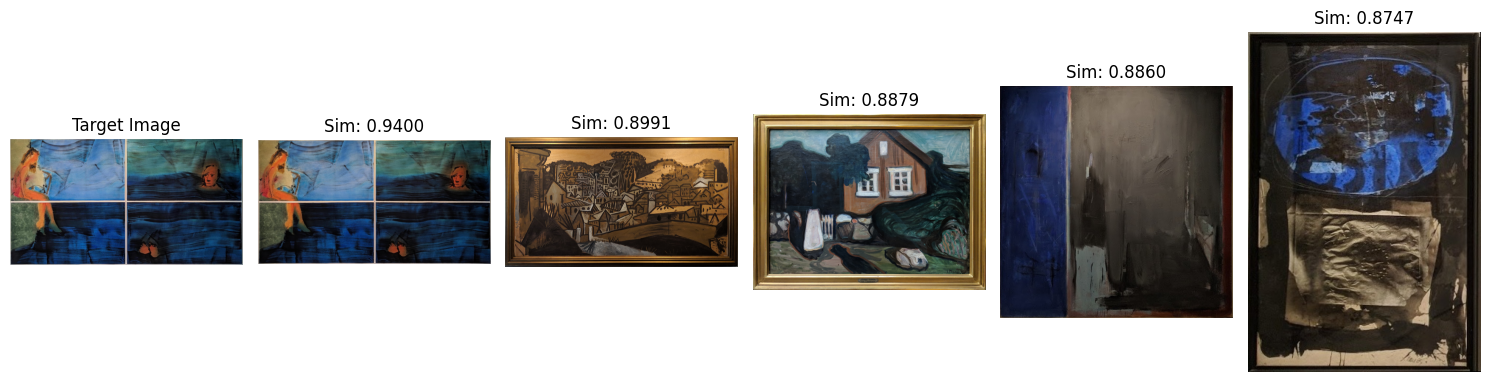

,image_path,artist,artwork_name,similarity
227,data/BBDD/bbdd_00227.jpg,Perico Pastor,Mezzo,0.940001
31,data/BBDD/bbdd_00031.jpg,Pablo Picasso,Vallauris,0.899116
69,data/BBDD/bbdd_00069.jpg,Edvard Munch,House in Moonlight,0.887881
80,data/BBDD/bbdd_00080.jpg,None,None,0.886047
157,data/BBDD/bbdd_00157.jpg,Antoni Clave,Ovale et etoiles,0.874706


In [13]:
find_similar_images(test_dataset["image"].iloc[3], dataset, top_n=5, plot=True, bins=BINS)

## Evaluation of bin number and distance metric

In [14]:
import pickle

# Load the ground-truth correspondence for each test image.
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

# Each entry contains the zero-based index of the matching training image.
correspondence_indices = [
    match[0] if match else None
    for match in correspondences
]

train_rows = dataset.reset_index(drop=True)
test_rows = test_dataset[test_dataset["image_path"].notna()].reset_index(drop=True)

correspondence_table = pd.DataFrame({
    "test_image": test_rows["image_path"],
    "train_index": correspondence_indices,
})
correspondence_table["train_image"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["image_path"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artist"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artist"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artwork_name"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artwork_name"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)

correspondence_table

,test_image,train_index,train_image,artist,artwork_name
0,data/qsd1_w1/00000.jpg,120,data/BBDD/bbdd_00120.jpg,Paul Klee,May come!
1,data/qsd1_w1/00001.jpg,170,data/BBDD/bbdd_00170.jpg,Alfred Figueras,Cap de Noia
2,data/qsd1_w1/00002.jpg,277,data/BBDD/bbdd_00277.jpg,Pere Santilari,Sifo groc
3,data/qsd1_w1/00003.jpg,227,data/BBDD/bbdd_00227.jpg,Perico Pastor,Mezzo
4,data/qsd1_w1/00004.jpg,251,data/BBDD/bbdd_00251.jpg,Francesc Artigau,Noia
5,data/qsd1_w1/00005.jpg,274,data/BBDD/bbdd_00274.jpg,Montserrat Clausells,Te de nit
6,data/qsd1_w1/00006.jpg,285,data/BBDD/bbdd_00285.jpg,Joan Hernandez Pijuan,Recordando una corrida
7,data/qsd1_w1/00007.jpg,258,data/BBDD/bbdd_00258.jpg,Sergi Barnils,"Mireu, tot ho faig nou"
8,data/qsd1_w1/00008.jpg,117,data/BBDD/bbdd_00117.jpg,Leticia Feduchi,Roba i cordill
9,data/qsd1_w1/00009.jpg,203,data/BBDD/bbdd_00203.jpg,Francesc Artigau,Retrat d'una noia


In [15]:
def create_bin_histograms(dataset, bins=BINS):
    """
    Create histograms for each image in the dataset.

    Parameters:
    dataset (pd.DataFrame): The dataset containing images.
    bins (int): The number of bins for the histogram.

    Returns:
    pd.DataFrame: The dataset with an additional column for histograms.
    """
    dataset["histogram"] = dataset["image"].apply(
        lambda img: np.histogram(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), bins=bins, range=(0, 256))[0]
    )
    return dataset

In [16]:
binlist = [32, 64, 128, 256]

distance_metrics = {"Correlation":cv2.HISTCMP_CORREL,
                    "Intersect":cv2.HISTCMP_INTERSECT,
                    "Chi squared":cv2.HISTCMP_CHISQR,
                    "Battacharyya":cv2.HISTCMP_BHATTACHARYYA}

results = pd.DataFrame(columns=["bins", "distance_metric", "top1_accuracy", "top5_accuracy"])

# comparison using top 1 and top 5 accuracy with different histogram bin sizes
for bins in binlist:
    for distance_metric in distance_metrics.keys():
        print(f"Evaluating with {bins} bins and distance metric {distance_metric}:")
        dataset_with_histograms = create_bin_histograms(dataset.copy(), bins=bins)

        top1_correct = 0
        top5_correct = 0
        total_images = len(test_rows)

        for idx, test_row in test_rows.iterrows():
            target_image = test_row["image"]
            similar_images = find_similar_images(target_image, dataset_with_histograms, top_n=5, plot=False, bins=bins, method=distance_metrics[distance_metric])

            # Check if the correct match is in the top 1
            if similar_images.iloc[0]["image_path"] == correspondence_table.iloc[idx]["train_image"]:
                top1_correct += 1

            # Check if the correct match is in the top 5
            if correspondence_table.iloc[idx]["train_image"] in similar_images["image_path"].values:
                top5_correct += 1

        top1_accuracy = top1_correct / total_images
        top5_accuracy = top5_correct / total_images

        results.loc[len(results)] = {
            "bins": bins,
            "distance_metric": distance_metric,
            "top1_accuracy": top1_accuracy,
            "top5_accuracy": top5_accuracy
        }

        print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
        print(f"Top-5 Accuracy: {top5_accuracy:.4f}\n")

Evaluating with 32 bins and distance metric Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

Evaluating with 32 bins and distance metric Intersect:
Top-1 Accuracy: 0.0667
Top-5 Accuracy: 0.0667

Evaluating with 32 bins and distance metric Chi squared:
Top-1 Accuracy: 0.0333
Top-5 Accuracy: 0.0667

Evaluating with 32 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

Evaluating with 64 bins and distance metric Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

Evaluating with 64 bins and distance metric Intersect:
Top-1 Accuracy: 0.0333
Top-5 Accuracy: 0.0667

Evaluating with 64 bins and distance metric Chi squared:
Top-1 Accuracy: 0.0333
Top-5 Accuracy: 0.0667

Evaluating with 64 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3667

Evaluating with 128 bins and distance metric Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

Evaluating with 128 bins and distance metric Intersect:
Top-1 Acc

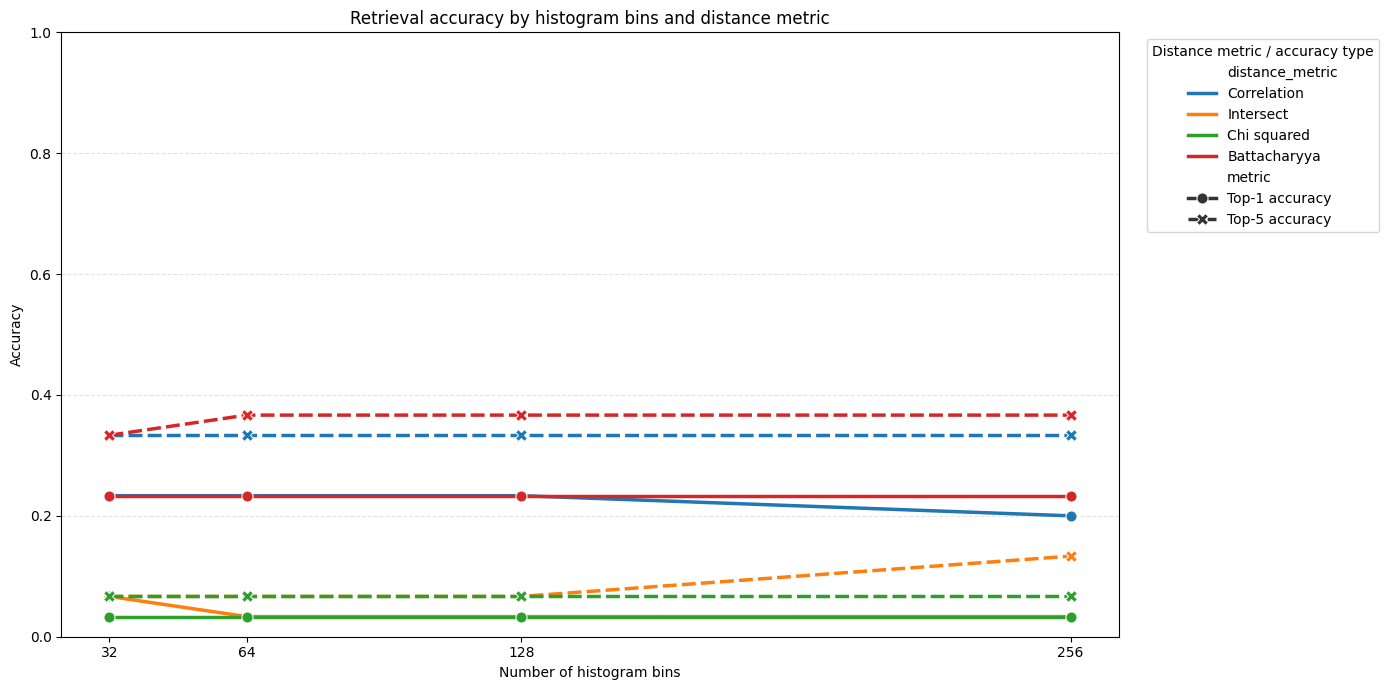

In [17]:
# Plot top-1 and top-5 accuracy for every distance metric and bin count
plot_data = results.melt(
    id_vars=["bins", "distance_metric"],
    value_vars=["top1_accuracy", "top5_accuracy"],
    var_name="metric",
    value_name="accuracy"
)
plot_data["metric"] = plot_data["metric"].map({
    "top1_accuracy": "Top-1 accuracy",
    "top5_accuracy": "Top-5 accuracy"
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_data,
    x="bins",
    y="accuracy",
    hue="distance_metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=8
)

plt.title("Retrieval accuracy by histogram bins and distance metric")
plt.xlabel("Number of histogram bins")
plt.ylabel("Accuracy")
plt.xticks(binlist)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Distance metric / accuracy type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

- Bhattacharyya is the best metric : 23% in top 1 and 33 to 37% top 5 accuracy. 
- Correlation is almost the same ( 23% top 1, 33% top-5). 
- Intersect (3 to 7% top-1, 7 to 13% top-5) and Chi (3% top-1, 7% top-5) are far behind. Why? 
    - Both metrics compare raw pixel counts bin by bin, so an image with more pixels has bigger counts in every bin. Intersect and Chi squared then end up measuring the size difference between the two images instead of how their brightness is distributed.
    - Intesect measures how much is shared and chi measure how different each bin is


## Normalized histograms

In order to avoid the image size to be a problem for the metrics that count pixels, we normalize the histograms: each histogram is divided by its total, so it adds up to 1 and the image size no longer matters.

In [20]:
def gray_histogram_norm(img, bins):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hist = np.histogram(gray, bins=bins, range=(0, 256))[0].astype(np.float32)
    return hist / hist.sum()    # divide by the number of pixels


def find_similar_images_norm(target_image, dataset, top_n=5, method=cv2.HISTCMP_CORREL, bins=256):
    target_histogram = gray_histogram_norm(target_image, bins)

    dataset["similarity"] = dataset["histogram"].apply(
        lambda hist: cv2.compareHist(target_histogram, hist.astype(np.float32), method)
    )

    # correlation and intersection: higher = more similar; chi-squared and Bhattacharyya: lower = more similar
    higher_is_better = method in (cv2.HISTCMP_CORREL, cv2.HISTCMP_INTERSECT)
    similar_images = dataset.sort_values(by="similarity", ascending=not higher_is_better).head(top_n)

    return similar_images[["image_path", "artist", "artwork_name", "similarity"]]

In [21]:
results_norm = pd.DataFrame(columns=["bins", "distance_metric", "top1_accuracy", "top5_accuracy"])

for bins in binlist:
    # museum histograms, normalized, for this number of bins
    dataset_norm = dataset.copy()
    dataset_norm["histogram"] = dataset_norm["image"].apply(lambda img: gray_histogram_norm(img, bins))

    for distance_metric in distance_metrics.keys():
        print(f"[normalized] {bins} bins, {distance_metric}:")

        top1_correct = 0
        top5_correct = 0
        total_images = len(test_rows)

        for idx, test_row in test_rows.iterrows():
            similar_images = find_similar_images_norm(test_row["image"], dataset_norm, top_n=5, method=distance_metrics[distance_metric], bins=bins)

            # Top 1: the first result is the correct painting
            if similar_images.iloc[0]["image_path"] == correspondence_table.iloc[idx]["train_image"]:
                top1_correct += 1

            # Top 5: the correct painting is among the 5 results
            if correspondence_table.iloc[idx]["train_image"] in similar_images["image_path"].values:
                top5_correct += 1

        results_norm.loc[len(results_norm)] = {
            "bins": bins,
            "distance_metric": distance_metric,
            "top1_accuracy": top1_correct / total_images,
            "top5_accuracy": top5_correct / total_images
        }

        print(f"Top-1 Accuracy: {top1_correct / total_images:.4f}")
        print(f"Top-5 Accuracy: {top5_correct / total_images:.4f}\n")

[normalized] 32 bins, Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

[normalized] 32 bins, Intersect:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3333

[normalized] 32 bins, Chi squared:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3000

[normalized] 32 bins, Battacharyya:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

[normalized] 64 bins, Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

[normalized] 64 bins, Intersect:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3333

[normalized] 64 bins, Chi squared:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.2667

[normalized] 64 bins, Battacharyya:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3667

[normalized] 128 bins, Correlation:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3333

[normalized] 128 bins, Intersect:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3333

[normalized] 128 bins, Chi squared:
Top-1 Accuracy: 0.2000
Top-5 Accuracy: 0.2667

[normalized] 128 bins, Battacharyya:
Top-1 Accuracy: 0.2333
Top-5 Accuracy: 0.3667

[normalized] 25

In [ ]:
# raw counts (first experiment) vs normalized histograms
comparison = results.assign(bins=results["bins"].astype(int)).merge(
    results_norm.assign(bins=results_norm["bins"].astype(int)),
    on=["bins", "distance_metric"],
    suffixes=("_raw", "_norm"),
)
accuracy_columns = [c for c in comparison.columns if "accuracy" in c]
comparison[accuracy_columns] = comparison[accuracy_columns].astype(float).round(3)
comparison

,bins,distance_metric,top1_accuracy_raw,top5_accuracy_raw,top1_accuracy_norm,top5_accuracy_norm
0,32,Correlation,0.233,0.333,0.233,0.333
1,32,Intersect,0.067,0.067,0.300,0.333
2,32,Chi squared,0.033,0.067,0.300,0.300
3,32,Battacharyya,0.233,0.333,0.233,0.333
4,64,Correlation,0.233,0.333,0.233,0.333
5,64,Intersect,0.033,0.067,0.267,0.333
6,64,Chi squared,0.033,0.067,0.233,0.267
7,64,Battacharyya,0.233,0.367,0.233,0.367
8,128,Correlation,0.233,0.333,0.233,0.333
9,128,Intersect,0.033,0.067,0.267,0.333


In [23]:
# Check: Correlation and Bhattacharyya already ignore image size, so they should not change
for metric in ["Correlation", "Battacharyya"]:
    sub = comparison[comparison["distance_metric"] == metric]
    unchanged = (sub["top1_accuracy_raw"] == sub["top1_accuracy_norm"]).all() and (sub["top5_accuracy_raw"] == sub["top5_accuracy_norm"]).all()
    print(f"{metric}: unchanged after normalizing -> {unchanged}")

Correlation: unchanged after normalizing -> True
Battacharyya: unchanged after normalizing -> True


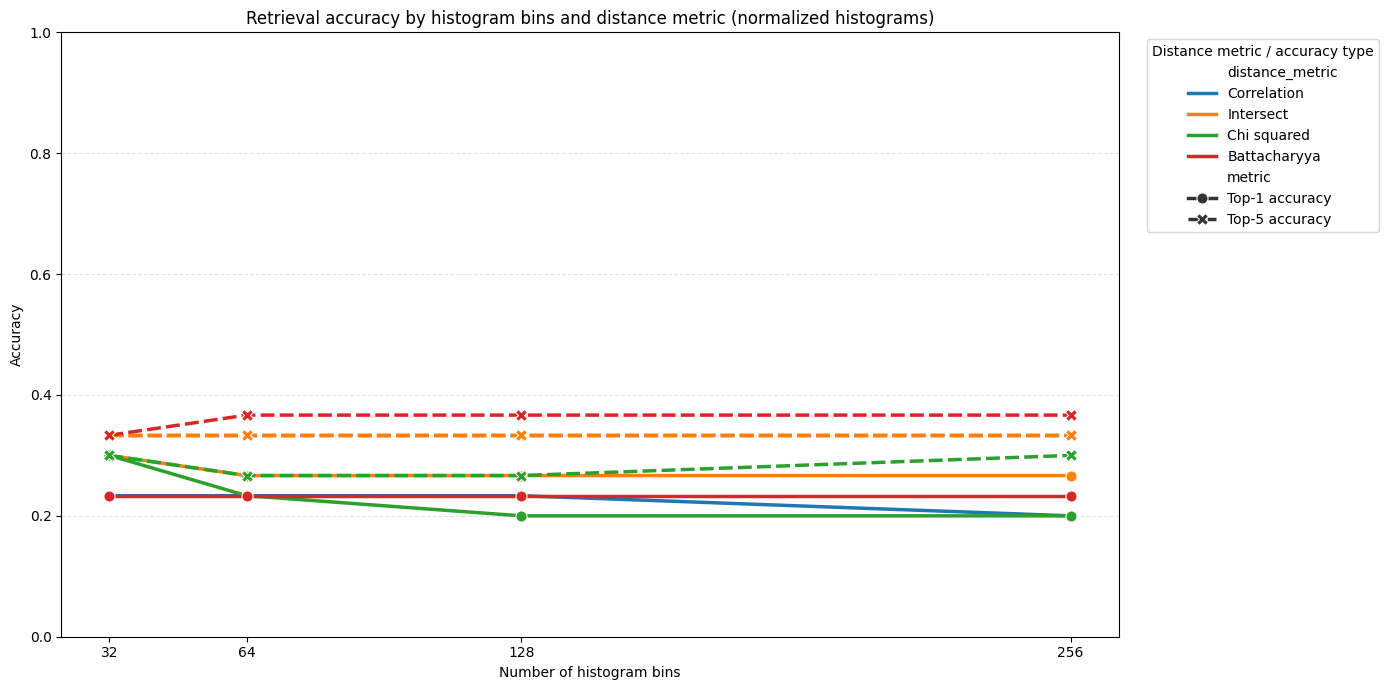

In [24]:
# Plot top-1 and top-5 accuracy with normalized histograms
plot_data_norm = results_norm.melt(
    id_vars=["bins", "distance_metric"],
    value_vars=["top1_accuracy", "top5_accuracy"],
    var_name="metric",
    value_name="accuracy"
)
plot_data_norm["accuracy"] = plot_data_norm["accuracy"].astype(float)
plot_data_norm["bins"] = plot_data_norm["bins"].astype(int)
plot_data_norm["metric"] = plot_data_norm["metric"].map({
    "top1_accuracy": "Top-1 accuracy",
    "top5_accuracy": "Top-5 accuracy"
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_data_norm,
    x="bins",
    y="accuracy",
    hue="distance_metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=8
)

plt.title("Retrieval accuracy by histogram bins and distance metric (normalized histograms)")
plt.xlabel("Number of histogram bins")
plt.ylabel("Accuracy")
plt.xticks(binlist)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Distance metric / accuracy type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The big change from normalizing is that Intersect and Chi squared went from 3 to 7% top-1 up to 20 to 30%, while Correlation and Bhattacharyya stayed the same.

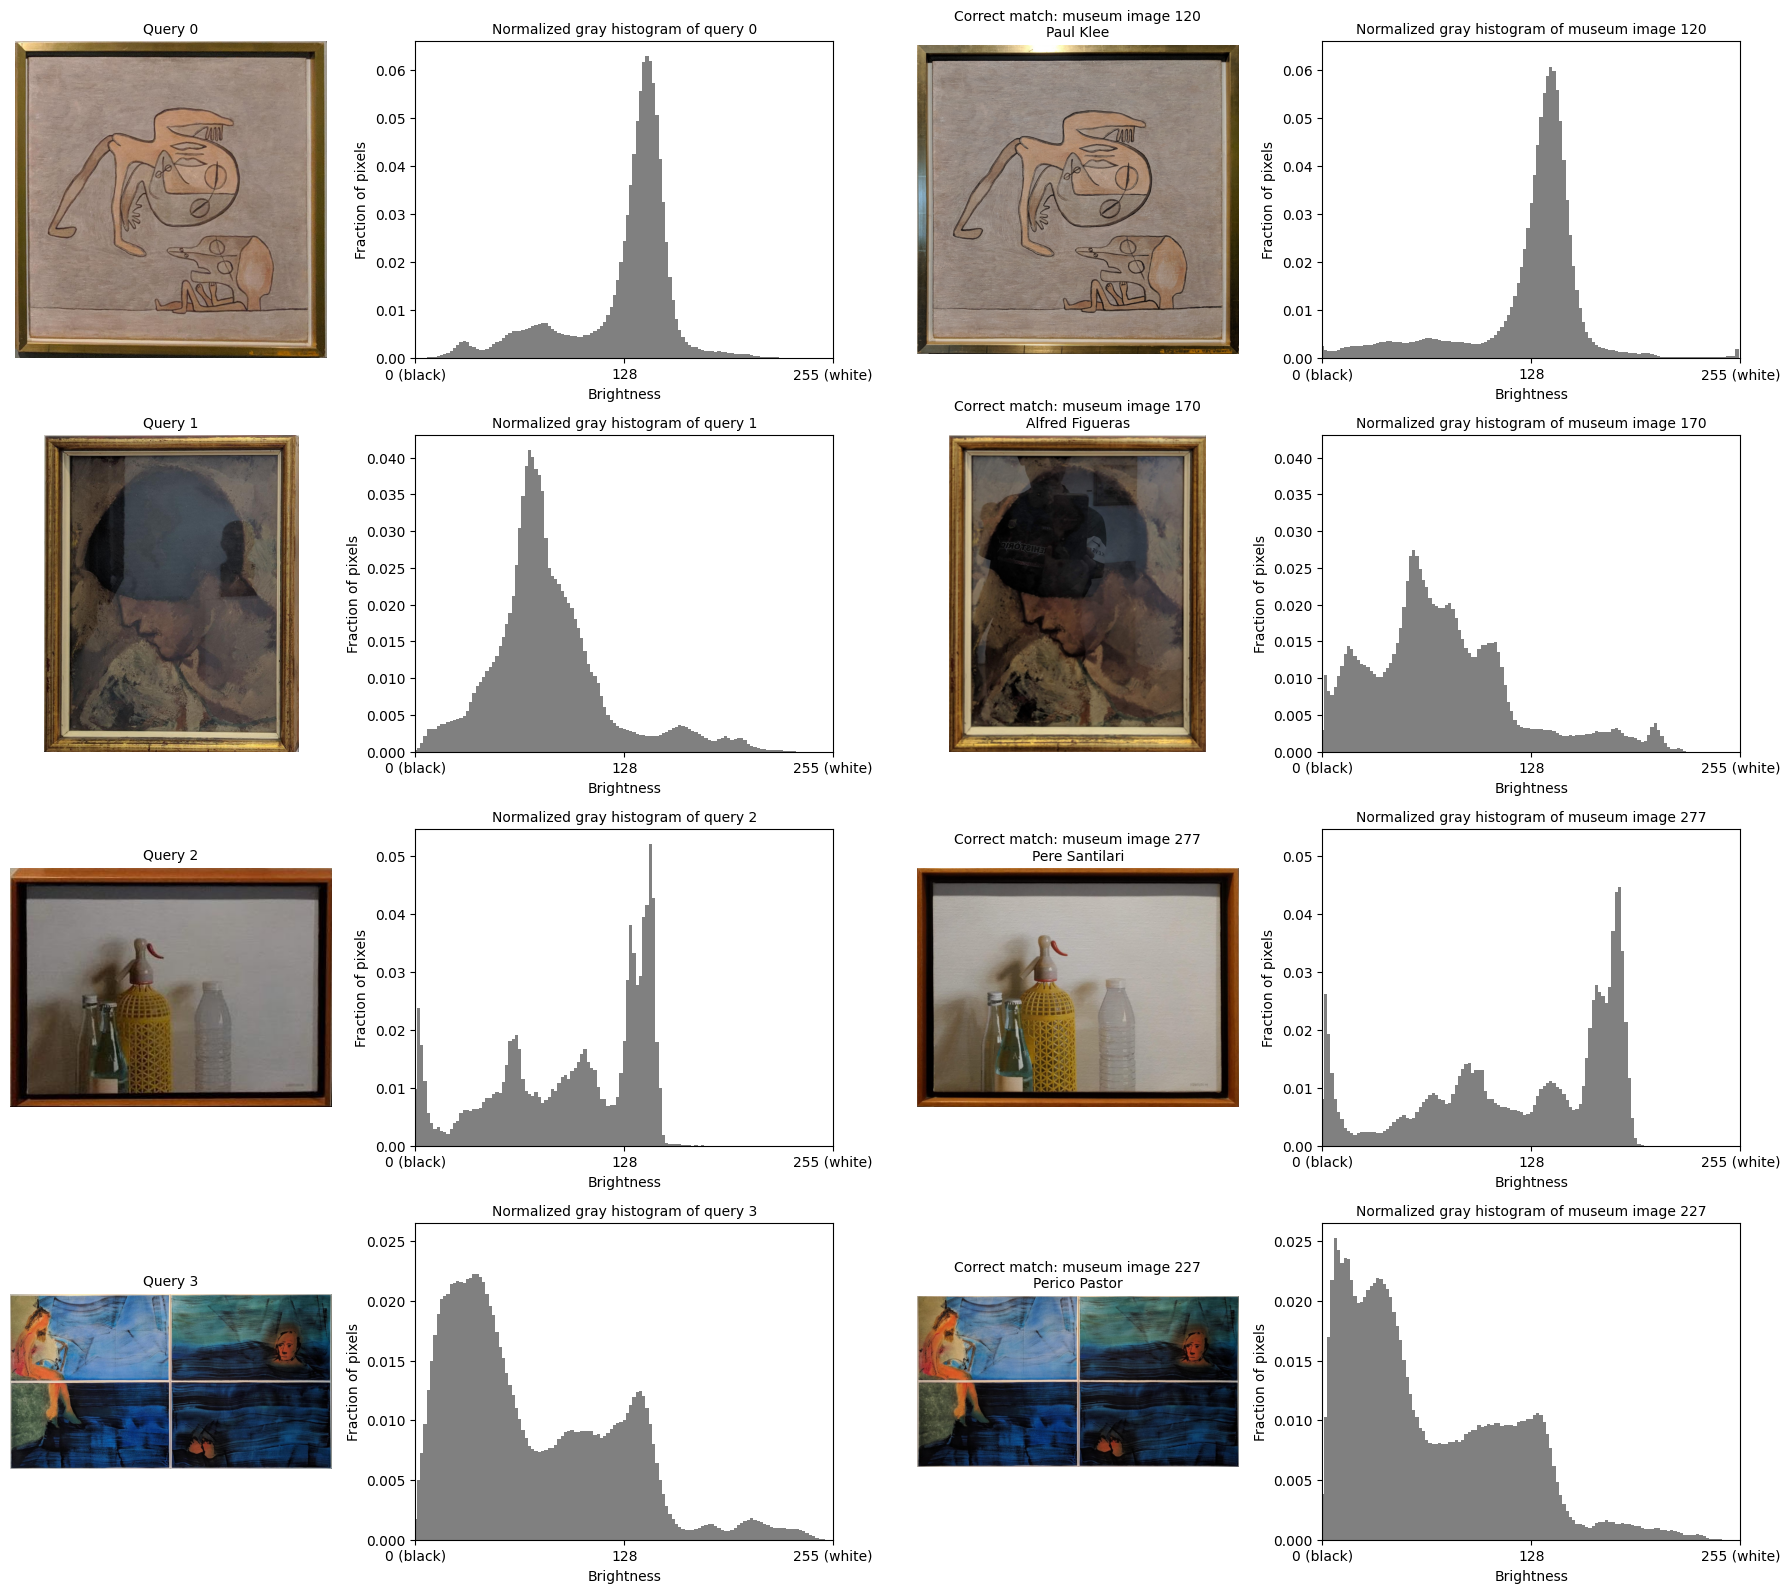

In [ ]:
# Same plot but with normalized histograms 
query_indices = [0, 1, 2, 3]     # queries


def gray_hist_norm(img):
    hist = np.histogram(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), bins=BINS, range=(0, 256))[0].astype(float)
    return hist / hist.sum()    # divide by the number of pixels


def draw_hist_norm(ax, hist, title, ymax):
    ax.bar(np.arange(len(hist)), hist, color="gray", width=1.0)
    ax.set_xlim(0, len(hist))
    ax.set_ylim(0, ymax)
    ax.set_xticks([0, len(hist) / 2, len(hist)])
    ax.set_xticklabels(["0 (black)", "128", "255 (white)"])
    ax.set_xlabel("Brightness")
    ax.set_ylabel("Fraction of pixels")
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(
    len(query_indices), 4,
    figsize=(18, 4 * len(query_indices)),
    gridspec_kw={"width_ratios": [1, 1.3, 1, 1.3]},
    squeeze=False,
)

for row, q in enumerate(query_indices):
    j = int(correspondence_table.iloc[q]["train_index"])    # position of the correct painting in the museum
    query_img = test_rows["image"].iloc[q]
    match_img = train_rows["image"].iloc[j]
    ax_query, ax_query_hist, ax_match, ax_match_hist = axes[row]

    query_hist = gray_hist_norm(query_img)
    match_hist = gray_hist_norm(match_img)
    ymax = 1.05 * max(query_hist.max(), match_hist.max())    # same vertical scale for both histograms

    # query: picture and histogram
    ax_query.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
    ax_query.set_title(f"Query {q}", fontsize=10)
    ax_query.axis("off")
    draw_hist_norm(ax_query_hist, query_hist, f"Normalized gray histogram of query {q}", ymax)

    # correct museum painting: picture and histogram
    ax_match.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    ax_match.set_title(f"Correct match: museum image {j}\n{train_rows['artist'].iloc[j]}", fontsize=10)
    ax_match.axis("off")
    draw_hist_norm(ax_match_hist, match_hist, f"Normalized gray histogram of museum image {j}", ymax)

plt.tight_layout()
plt.show()